# 넷플릭스 주가 예측하기 RNN 코드 실습

## 1. 데이터 가져오기

In [1]:
# 데이터 가져오기
import pandas as pd
data = pd.read_csv("netflix_train.csv")
data.head()

,Date,Open,High,Low,Volume,Close
0,2015-12-16,120,123,118,13181000,123
1,2015-12-17,124,126,122,17284900,123
2,2015-12-18,121,122,118,17948100,118
3,2015-12-21,120,120,116,11670000,117
4,2015-12-22,117,117,115,9689000,116


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 967 entries, 0 to 966
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    967 non-null    object
 1   Open    967 non-null    int64 
 2   High    967 non-null    int64 
 3   Low     967 non-null    int64 
 4   Volume  967 non-null    int64 
 5   Close   967 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 45.5+ KB


/tmp/ipykernel_18655/2074775871.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_used["Close"] = data["Close"]


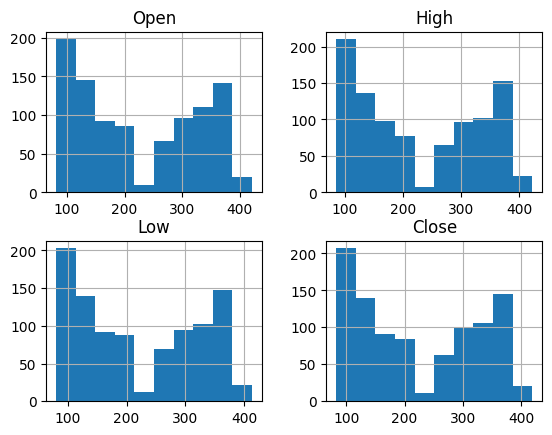

In [3]:
# 데이터 분포를 히스토그램으로 살펴보기
import matplotlib.pyplot as plt

# 개장가, 최고가, 최저가 추가
data_used = data[["Open", "High", "Low"]]
# 종가 추가
data_used["Close"] = data["Close"]
hist = data_used.hist()
plt.show()

## 2. 파이토치 데이터셋 구성하기

In [6]:
import numpy as np
from torch.utils.data.dataset import Dataset

class Netflix(Dataset):  # 클래스 선언
   def __init__(self):
       # 데이터 읽기
       self.csv = pd.read_csv("netflix_train.csv")

       # 입력 데이터 정규화
       # 종가를 제외한 데이터
       self.data = self.csv[["Open", "High", "Low"]].values
       # 0과 1 사이로 정규화
       self.data = (self.data - self.data.min(axis=0)) / (self.data.max(axis=0) - self.data.min(axis=0))

       # 종가 데이터 정규화
       self.label = self.csv["Close"].values
       self.label = (self.label - self.label.min()) / (self.label.max() - self.label.min())

   def __len__(self):
       return len(self.data) - 30 # 사용 가능한 배치 개수

   def __getitem__(self, i):
        # 입력 데이터 30일치 읽기
        data = self.data[i:i+30]
        # 종가 데이터 30일치 읽기
        label = self.label[i+30]

        return data, label

## 3. RNN 모델 정의

In [7]:
# RNN 클래스 정의

import torch
import torch.nn as nn

class RNN(nn.Module):
   def __init__(self):
       super(RNN, self).__init__()

       # RNN층의 정의
       self.rnn = nn.RNN(input_size=3, hidden_size=8, num_layers=5, batch_first=True)


       # 주가를 예측하는 MLP층 정의
       self.fc1 = nn.Linear(in_features=240, out_features=64)
       self.fc2 = nn.Linear(in_features=64, out_features=1)


       # 활성화 함수 정의
       self.relu = nn.ReLU()

# RNN 모델의 순전파 정의
   def forward(self, x, h0):
       # RNN층의 출력
       x, hn = self.rnn(x, h0)

       # MLP층의 입력으로 사용되게 모양 변경
       x = torch.reshape(x, (x.size(0), -1))


       # MLP층을 이용해 종가 예측
       x = self.fc1(x)
       x = self.relu(x)
       x = self.fc2(x)


       # 예측한 종가를 1차원 벡터로 표현
       x = torch.squeeze(x)


       return x

## 4. 모델 학습하기

In [8]:
# 모델과 데이터셋 정의
import tqdm
from torch.optim.adam import Adam
from torch.utils.data.dataloader import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

# 모델의 정의
model = RNN().to(device)
# 데이터셋의 정의
dataset = Netflix()

In [9]:
# 데이터로더 정의
# 배치 크기를 32로 설정
loader = DataLoader(dataset, batch_size=32)

In [10]:
# 최적화 정의
# 학습률은 0.0001로 설정
# 사용할 최적화 설정
optim = Adam(params=model.parameters(), lr=0.0001)

In [14]:
# 학습 루프 정의
# 에포크: 200
for epoch in range(200):
   iterator = tqdm.tqdm(loader)
   for data, label in iterator:
       optim.zero_grad()

       # 초기 은닉 상태
       h0 = torch.zeros(5,data.shape[0],8).to(device)


       # 모델의 예측값
       pred = model(data.type(torch.FloatTensor).to(device), h0)

       # 손실 계산
       loss = nn.MSELoss()(pred, label.type(torch.FloatTensor).to(device))


       # 손실의 계산
       loss = nn.MSELoss()(pred, label.type(torch.FloatTensor).to(device))

       # 오차 역전파
       loss.backward()
       # 최적화 진행
       optim.step()

       iterator.set_description(f"epoch{epoch} loss:{loss.item()}")

  # 모델 저장
torch.save(model.state_dict(), "netflix_rnn.pth")

epoch199 loss:0.00045546842738986015: 100%|██████████| 30/30 [00:00<00:00, 45.84it/s]


## 5. 모델 성능 평가하기

In [15]:
import matplotlib.pyplot as plt

# 예측값을 위한 데이터로더
loader = DataLoader(dataset, batch_size=1)

# 예측값들을 저장하는 리스트
preds=[]
total_loss = 0

with torch.no_grad():
   # 모델의 가중치 불러오기
   model.load_state_dict(torch.load("netflix_rnn.pth",map_location=device))


   for data, label in loader:

       # 초기 은닉 상태 정의
       h0 = torch.zeros(5, data.shape[0], 8).to(device)

       # 모델의 예측값 출력
       pred = model(data.type(torch.FloatTensor).to(device), h0)

       # 예측값을 리스트에 추가
       preds.append(pred.item())

       # 손실 계산
       loss = nn.MSELoss()(pred,label.type(torch.FloatTensor).to(device))

       # 손실의 평균치 계산
       total_loss += loss/len(loader)


total_loss.item()

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


0.0017477248329669237

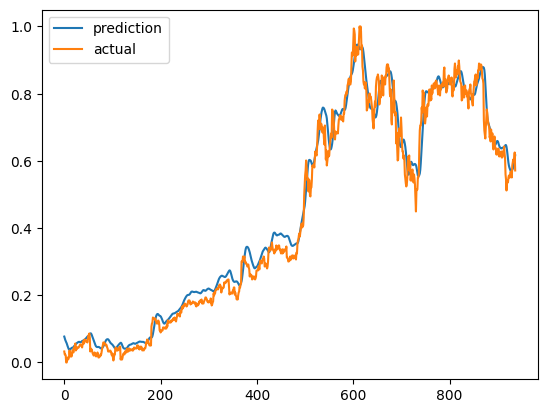

In [16]:
# 그래프 출력
plt.plot(preds, label="prediction")
plt.plot(dataset.label[30:], label="actual")
plt.legend()
plt.show()